In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
data = pd.DataFrame({
    "company": ["A", "B", "C", "D", "E", "F"],
    "sector": ["Tech", "Finance", "Tech", "Retail", "Finance", "Retail"],
    "co2_emissions": [120, 300, 150, 80, 260, 100],
    "energy_usage": [400, 900, 500, 300, 800, 350],
    "employees": [50, 200, 80, 40, 150, 60]
})

data

,company,sector,co2_emissions,energy_usage,employees
0,A,Tech,120,400,50
1,B,Finance,300,900,200
2,C,Tech,150,500,80
3,D,Retail,80,300,40
4,E,Finance,260,800,150
5,F,Retail,100,350,60


In [6]:
data.head()

,company,sector,co2_emissions,energy_usage,employees
0,A,Tech,120,400,50
1,B,Finance,300,900,200
2,C,Tech,150,500,80
3,D,Retail,80,300,40
4,E,Finance,260,800,150


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   company        6 non-null      object
 1   sector         6 non-null      object
 2   co2_emissions  6 non-null      int64 
 3   energy_usage   6 non-null      int64 
 4   employees      6 non-null      int64 
dtypes: int64(3), object(2)
memory usage: 372.0+ bytes


In [ ]:
# select
data["company"]

0    A
1    B
2    C
3    D
4    E
5    F
Name: company, dtype: object

In [4]:
#filter rows
data[data["sector"] == "Tech"]


,company,sector,co2_emissions,energy_usage,employees
0,A,Tech,120,400,50
2,C,Tech,150,500,80


In [7]:
#sort values

data.sort_values("co2_emissions", ascending=False)

,company,sector,co2_emissions,energy_usage,employees
1,B,Finance,300,900,200
4,E,Finance,260,800,150
2,C,Tech,150,500,80
0,A,Tech,120,400,50
5,F,Retail,100,350,60
3,D,Retail,80,300,40


In [8]:
#summary
data.describe()

,co2_emissions,energy_usage,employees
count,6.000000,6.000000,6.000000
mean,168.333333,541.666667,96.666667
std,90.424923,249.833278,64.083279
min,80.000000,300.000000,40.000000
25%,105.000000,362.500000,52.500000
50%,135.000000,450.000000,70.000000
75%,232.500000,725.000000,132.500000
max,300.000000,900.000000,200.000000


In [9]:
#group by
data.groupby("sector")["co2_emissions"].mean()


sector
Finance    280.0
Retail      90.0
Tech       135.0
Name: co2_emissions, dtype: float64

In [ ]:
# feature engineering - create a new column for emissions per employee
data["emissions_per_employee"] = data["co2_emissions"] / data["employees"]
data

,company,sector,co2_emissions,energy_usage,employees,emissions_per_employee
0,A,Tech,120,400,50,2.400000
1,B,Finance,300,900,200,1.500000
2,C,Tech,150,500,80,1.875000
3,D,Retail,80,300,40,2.000000
4,E,Finance,260,800,150,1.733333
5,F,Retail,100,350,60,1.666667


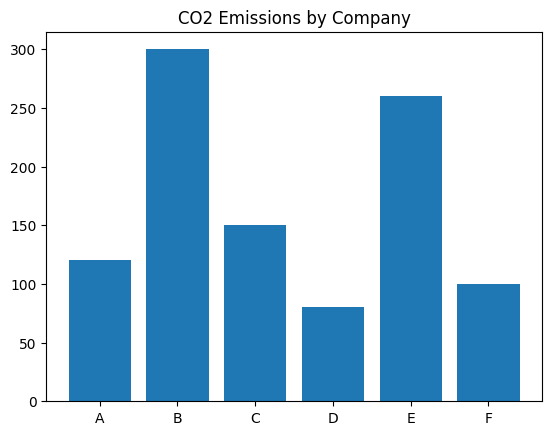

In [11]:
# visual 

plt.bar(data["company"], data["co2_emissions"])
plt.title("CO2 Emissions by Company")
plt.show()

In [6]:
kpis = data.groupby("sector").agg(
    avg_emissions=("co2_emissions", "mean"),
    total_emissions=("co2_emissions", "sum"),
    avg_employees=("employees", "mean")
).reset_index()

kpis
# KPI table showing average emissions, total emissions, and average employees by sector
#used to identify which sectors have the highest emissions and employee counts, helping to prioritize areas for improvement.


,sector,avg_emissions,total_emissions,avg_employees
0,Finance,280.0,560,175.0
1,Retail,90.0,180,50.0
2,Tech,135.0,270,65.0


In [ ]:
data["emissions_per_employee"] = data["co2_emissions"] / data["employees"]

data.sort_values("emissions_per_employee", ascending=False)

# feature engineering- create a new column for energy efficiency (energy usage per employee)

,company,sector,co2_emissions,energy_usage,employees,emissions_per_employee
0,A,Tech,120,400,50,2.400000
3,D,Retail,80,300,40,2.000000
2,C,Tech,150,500,80,1.875000
4,E,Finance,260,800,150,1.733333
5,F,Retail,100,350,60,1.666667
1,B,Finance,300,900,200,1.500000


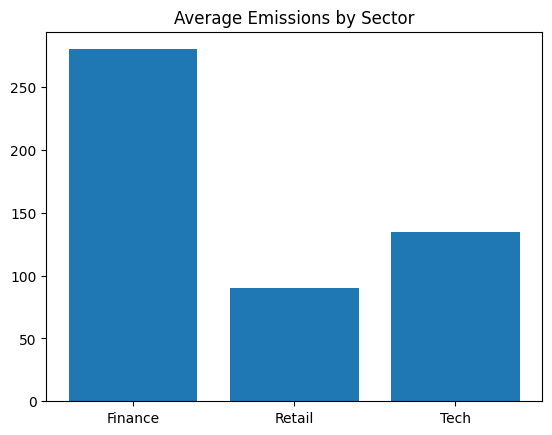

In [7]:
plt.bar(kpis["sector"], kpis["avg_emissions"])
plt.title("Average Emissions by Sector")
plt.show()

In [8]:
targets = pd.DataFrame({ "sector": ["Tech", "Finance", "Retail"],
                        "target_emissions": [100.0, 220.0, 90.0]})
targets

# KPI table showing target emissions by sector

,sector,target_emissions
0,Tech,100.0
1,Finance,220.0
2,Retail,90.0


In [10]:
merged = data.merge(targets, on="sector")
merged

# joined comany data with sector targets to compare actual emissions with targets, allowing for performance evaluation and identification of companies that are exceeding or falling short of their emission goals.


,company,sector,co2_emissions,energy_usage,employees,emissions_per_employee,target_emissions
0,A,Tech,120,400,50,2.400000,100.0
1,B,Finance,300,900,200,1.500000,220.0
2,C,Tech,150,500,80,1.875000,100.0
3,D,Retail,80,300,40,2.000000,90.0
4,E,Finance,260,800,150,1.733333,220.0
5,F,Retail,100,350,60,1.666667,90.0


In [ ]:
merged [["company", "sector", "co2_emissions", "target_emissions"]]

#selecting columns

,company,sector,co2_emissions,target_emissions
0,A,Tech,120,100.0
1,B,Finance,300,220.0
2,C,Tech,150,100.0
3,D,Retail,80,90.0
4,E,Finance,260,220.0
5,F,Retail,100,90.0


In [15]:
merged [merged["co2_emissions"] > merged ["target_emissions"]]

# filtering companies that are exceeding their emission targets

,company,sector,co2_emissions,energy_usage,employees,emissions_per_employee,target_emissions
0,A,Tech,120,400,50,2.400000,100.0
1,B,Finance,300,900,200,1.500000,220.0
2,C,Tech,150,500,80,1.875000,100.0
4,E,Finance,260,800,150,1.733333,220.0
5,F,Retail,100,350,60,1.666667,90.0


In [16]:
merged[merged["sector"] == "Finance"]

,company,sector,co2_emissions,energy_usage,employees,emissions_per_employee,target_emissions
1,B,Finance,300,900,200,1.500000,220.0
4,E,Finance,260,800,150,1.733333,220.0


In [ ]:
merged.sort_values("co2_emissions", ascending=False)

# sorting merged data to identify companies with the highest emissions compared to their targets, facilitating targeted interventions and resource allocation.

,company,sector,co2_emissions,energy_usage,employees,emissions_per_employee,target_emissions
0,A,Tech,120,400,50,2.400000,100.0
3,D,Retail,80,300,40,2.000000,90.0
2,C,Tech,150,500,80,1.875000,100.0
4,E,Finance,260,800,150,1.733333,220.0
5,F,Retail,100,350,60,1.666667,90.0
1,B,Finance,300,900,200,1.500000,220.0


In [ ]:
merged.sort_values("emissions_per_employee", ascending=False)

# sorting merged data by emissions per employee to identify companies with the highest emissions intensity, enabling more effective benchmarking and improvement strategies.

,company,sector,co2_emissions,energy_usage,employees,emissions_per_employee,target_emissions
0,A,Tech,120,400,50,2.400000,100.0
3,D,Retail,80,300,40,2.000000,90.0
2,C,Tech,150,500,80,1.875000,100.0
4,E,Finance,260,800,150,1.733333,220.0
5,F,Retail,100,350,60,1.666667,90.0
1,B,Finance,300,900,200,1.500000,220.0


In [23]:
merged["status"] = merged["co2_emissions"].apply(
    lambda x: "High" if x > 200 else "Acceptable"
)

merged

# added a new column "status" to classify companies as "High" or "Acceptable" based on their CO2 emissions, providing a clear indicator of performance relative to emission levels.
#apply - apply logic row-by-row
# lambda - anonymous function to classify emissions as "High" or "Acceptable" based on a threshold of 200.


,company,sector,co2_emissions,energy_usage,employees,emissions_per_employee,target_emissions,status
0,A,Tech,120,400,50,2.400000,100.0,Acceptable
1,B,Finance,300,900,200,1.500000,220.0,High
2,C,Tech,150,500,80,1.875000,100.0,Acceptable
3,D,Retail,80,300,40,2.000000,90.0,Acceptable
4,E,Finance,260,800,150,1.733333,220.0,High
5,F,Retail,100,350,60,1.666667,90.0,Acceptable
